# LoRA: Low-Rank Adaptation of Large Language Models

This notebook implements a miniature version of the LoRA algorithm
proposed in the paper:

LoRA: Low-Rank Adaptation of Large Language Models
https://arxiv.org/abs/2106.09685

Objective:
- Understand the mathematical foundation of LoRA.
- Implement parameter-efficient fine-tuning.
- Train a pretrained language model using a small dataset.
- Evaluate the impact of low-rank adaptation.

Due to hardware constraints, this implementation uses a smaller
pretrained model and a reduced dataset compared to the original paper.
The focus is understanding the algorithm and its implementation,
not reproducing the original large-scale experimental results.

### 1. Environment Setup

We install the libraries required for loading the pretrained language
model, processing the dataset, and implementing LoRA.

PyTorch provides the deep learning framework, while Hugging Face
Transformers and Datasets handle the model and dataset pipeline.

In [1]:
!pip -q install -U transformers datasets accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 30.4 MB/s eta 0:00:00


### 2. Import Required Libraries

We import the libraries needed for:
- Loading the pretrained language model and tokenizer.
- Loading and processing the dataset.
- Inspecting the model and managing the training configuration.

We will implement the core LoRA mechanism ourselves in later levels
to understand how the low-rank weight updates work.

This cell defines the main experiment configuration and random
seeds used throughout the notebook.

The experiment uses a fixed seed where possible. Results can
still vary depending on the hardware, software versions,
and sampling behavior during generation.

In [2]:
import os
import random
import numpy as np
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    set_seed
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch version:", torch.__version__)

Device: cuda
PyTorch version: 2.11.0+cu128


### 3. Pretrained Model Selection

We use DistilGPT2 as the base language model.

DistilGPT2 is a smaller GPT-2-based autoregressive language model,
making it suitable for experimentation in Google Colab.

The pretrained model will remain frozen during LoRA training.
Only the newly introduced low-rank adaptation parameters will be
updated in the later training stages.

In [3]:
MODEL_NAME = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

# GPT-2 models do not have a separate padding token.
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.pad_token_id

model.to(device)

print("Model:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)
print("Number of parameters:", model.num_parameters())

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: distilgpt2
Vocabulary size: 50257
Number of parameters: 81912576


### 4. Dataset Preparation

We use a subset of the Databricks Dolly instruction-following dataset
to create a manageable training workload.

The dataset contains instruction, context, and response fields.
We will combine these fields into a text prompt for causal language
modeling.

We use separate training and validation subsets to monitor
generalization and identify potential overfitting.

This dataset and setup are chosen for a practical demonstration
of LoRA, not an exact reproduction of the paper's experimental data.

In [4]:
DATASET_NAME = "databricks/databricks-dolly-15k"

dataset = load_dataset(DATASET_NAME)

print(dataset)
print(dataset["train"].column_names)

README.md:   0%|          | 0.00/8.20k [00:00<?, ?B/s]

databricks-dolly-15k.jsonl: reconstructing file:   0%|          |  0.00B / 13.1MB            

databricks-dolly-15k.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'context', 'response', 'category'],
        num_rows: 15011
    })
})
['instruction', 'context', 'response', 'category']


### 5. Training and Validation Split

We select 2,000 examples for training and 200 examples for validation.

The validation set is held out from training and will be used to
evaluate how well the adapted model performs on unseen examples.

We use a fixed random seed to make the subset selection reproducible.

In [5]:
full_dataset = dataset["train"].shuffle(seed=SEED)

train_dataset = full_dataset.select(range(2000))
validation_dataset = full_dataset.select(range(2000, 2200))

print("Training examples:", len(train_dataset))
print("Validation examples:", len(validation_dataset))

Training examples: 2000
Validation examples: 200


### 6. Inspect Dataset Examples

Before preprocessing, we inspect the structure of individual examples.

This helps us understand the instruction, optional context, and
response fields that will be used to construct the model input.

In [6]:
for i in range(2):
    sample = train_dataset[i]

    print(f"\n--- Example {i + 1} ---")
    print("Instruction:", sample["instruction"])
    print("Context:", sample["context"])
    print("Response:", sample["response"])


--- Example 1 ---
Instruction: Who were the children of the legendary Garth Greenhand, the High King of the First Men in the series A Song of Ice and Fire?
Context: 
Response: Garth the Gardener, John the Oak, Gilbert of the Vines, Brandon of the Bloody Blade, Foss the Archer, Owen Oakenshield, Harlon the Hunter, Herndon of the Horn, Bors the Breaker, Florys the Fox, Maris the Maid, Rose of the Red Lake, Ellyn Ever Sweet, Rowan Gold-Tree

--- Example 2 ---
Instruction: Give me a list of basic ingredients for baking cookies
Context: 
Response: To bake cookies you will need flour, sugar, eggs, milk, butter, baking powder, and if you want; you can add chocolate chips, cinnamon, walnuts, or macadamia nuts.  By combining the ingredients you will form a soft dough that you can scoop onto a baking sheet and bake in the oven until cooked thoroughly through.


### 7. Convert Examples into Training Text

We combine the instruction, context, and response into a single
text sequence.

The model will be trained using causal language modeling, where
the objective is to predict the next token in the sequence.

The response is included as part of the training text so that
the model learns to generate task-specific responses.

In [7]:
def format_example(example):
    instruction = example["instruction"].strip()
    context = example["context"].strip()
    response = example["response"].strip()

    if context:
        text = (
            f"Instruction: {instruction}\n"
            f"Context: {context}\n"
            f"Response: {response}"
        )
    else:
        text = (
            f"Instruction: {instruction}\n"
            f"Response: {response}"
        )

    return {"text": text}


train_text_dataset = train_dataset.map(
    format_example,
    remove_columns=train_dataset.column_names
)

validation_text_dataset = validation_dataset.map(
    format_example,
    remove_columns=validation_dataset.column_names
)

print(train_text_dataset[0]["text"])

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Instruction: Who were the children of the legendary Garth Greenhand, the High King of the First Men in the series A Song of Ice and Fire?
Response: Garth the Gardener, John the Oak, Gilbert of the Vines, Brandon of the Bloody Blade, Foss the Archer, Owen Oakenshield, Harlon the Hunter, Herndon of the Horn, Bors the Breaker, Florys the Fox, Maris the Maid, Rose of the Red Lake, Ellyn Ever Sweet, Rowan Gold-Tree


### 8. Tokenization

We convert the formatted text into token IDs using the pretrained
model's tokenizer.

A maximum sequence length of 256 tokens is used to limit GPU memory
consumption during training.

Sequences longer than this limit are truncated. Padding will be
handled during batch preparation in the next stage.

In [8]:
MAX_LENGTH = 256

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )


tokenized_train_dataset = train_text_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

tokenized_validation_dataset = validation_text_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

print(tokenized_train_dataset)
print(tokenized_train_dataset[0].keys())

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 2000
})
dict_keys(['input_ids', 'attention_mask'])


### 9. Tokenization Validation

We inspect the tokenized examples to verify that:
- Input IDs are generated correctly.
- The sequence length does not exceed the configured limit.
- The tokenizer is compatible with the pretrained model.

This ensures that the data is ready for batch preparation and training.

In [9]:
sample = tokenized_train_dataset[0]

print("Number of tokens:", len(sample["input_ids"]))
print("Maximum allowed tokens:", MAX_LENGTH)

decoded_text = tokenizer.decode(
    sample["input_ids"],
    skip_special_tokens=True
)

print("\nDecoded text:\n")
print(decoded_text)

Number of tokens: 111
Maximum allowed tokens: 256

Decoded text:

Instruction: Who were the children of the legendary Garth Greenhand, the High King of the First Men in the series A Song of Ice and Fire?
Response: Garth the Gardener, John the Oak, Gilbert of the Vines, Brandon of the Bloody Blade, Foss the Archer, Owen Oakenshield, Harlon the Hunter, Herndon of the Horn, Bors the Breaker, Florys the Fox, Maris the Maid, Rose of the Red Lake, Ellyn Ever Sweet, Rowan Gold-Tree


## 10. Baseline Evaluation and Architecture Inspection

Before modifying the pretrained model with LoRA, we evaluate its
initial text-generation behavior.

We will also inspect the model's Transformer architecture to identify
the attention projection layers that can be adapted using LoRA.

The baseline results will later be compared with the LoRA-fine-tuned model.

In [10]:
def generate_response(
    prompt,
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=80
):
    model.eval()

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )

    generated_text = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return generated_text

In [11]:
baseline_prompts = [
    "Instruction: Explain what machine learning is.\nResponse:",
    "Instruction: What are the benefits of saving money?\nResponse:",
    "Instruction: Explain the difference between stocks and bonds.\nResponse:"
]

for index, prompt in enumerate(baseline_prompts, start=1):
    print(f"\n{'=' * 80}")
    print(f"BASELINE EXAMPLE {index}")
    print(f"{'=' * 80}")

    response = generate_response(prompt)
    print(response)


BASELINE EXAMPLE 1
Instruction: Explain what machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response:

BASELINE EXAMPLE 2
Instruction: What are the benefits of saving money?
Response:
The answer is yes. The answer is yes. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no

BASELINE EXAMPLE 3
Instruction: Explain the difference between stocks and bonds.
Response:
The following is a summary of the responses to the following questions:
1. What is the difference be

## 11. Inspecting the Transformer Architecture

LoRA is applied to selected weight matrices inside the pretrained model.

The original LoRA paper studies attention projection matrices such as
Wq and Wv. Therefore, we need to inspect the actual architecture of
our selected model before implementing the LoRA layers.

DistilGPT2 uses GPT-2-style attention modules, where the query,
key, and value projections are combined into a single `c_attn` layer.

In [12]:
print("Attention-related modules:\n")

for name, module in model.named_modules():
    if "attn" in name:
        print(f"{name:<50} {module.__class__.__name__}")

Attention-related modules:

transformer.h.0.attn                               GPT2Attention
transformer.h.0.attn.c_attn                        Conv1D
transformer.h.0.attn.c_proj                        Conv1D
transformer.h.0.attn.attn_dropout                  Dropout
transformer.h.0.attn.resid_dropout                 Dropout
transformer.h.1.attn                               GPT2Attention
transformer.h.1.attn.c_attn                        Conv1D
transformer.h.1.attn.c_proj                        Conv1D
transformer.h.1.attn.attn_dropout                  Dropout
transformer.h.1.attn.resid_dropout                 Dropout
transformer.h.2.attn                               GPT2Attention
transformer.h.2.attn.c_attn                        Conv1D
transformer.h.2.attn.c_proj                        Conv1D
transformer.h.2.attn.attn_dropout                  Dropout
transformer.h.2.attn.resid_dropout                 Dropout
transformer.h.3.attn                               GPT2Attention
transforme

In [13]:
first_attention_layer = model.transformer.h[0].attn

print(first_attention_layer)

GPT2Attention(
  (c_attn): Conv1D(nf=2304, nx=768)
  (c_proj): Conv1D(nf=768, nx=768)
  (attn_dropout): Dropout(p=0.1, inplace=False)
  (resid_dropout): Dropout(p=0.1, inplace=False)
)


In [14]:
c_attn = first_attention_layer.c_attn

print("c_attn module:", c_attn)
print("Input features:", c_attn.nf // 3)
print("Output features:", c_attn.nf)

c_attn module: Conv1D(nf=2304, nx=768)
Input features: 768
Output features: 2304


In [15]:
print("Model configuration:\n")

print("Model name:", MODEL_NAME)
print("Hidden size:", model.config.n_embd)
print("Number of layers:", model.config.n_layer)
print("Number of attention heads:", model.config.n_head)
print("Vocabulary size:", model.config.vocab_size)
print("Maximum position embeddings:", model.config.n_positions)

Model configuration:

Model name: distilgpt2
Hidden size: 768
Number of layers: 6
Number of attention heads: 12
Vocabulary size: 50257
Maximum position embeddings: 1024


## 12. Initial LoRA Target

The original paper primarily applies LoRA to the query and value
projection matrices, Wq and Wv.

Our selected DistilGPT2 model combines query, key, and value projections
inside the `c_attn` module.

For this educational implementation, we will initially target the
combined `c_attn` projection. This is a practical adaptation for the
selected architecture, but it is not an exact reproduction of the
paper's separate Wq and Wv configuration.

The difference will be documented when comparing our implementation
with the original paper.

In [16]:
def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
    )


def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


total_parameters = count_parameters(model)
trainable_parameters = count_trainable_parameters(model)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters: 81,912,576
Trainable parameters: 81,912,576


In [17]:
baseline_total_parameters = count_parameters(model)
baseline_trainable_parameters = count_trainable_parameters(model)

print("Baseline parameter summary")
print("-" * 40)
print(f"Total parameters:     {baseline_total_parameters:,}")
print(f"Trainable parameters: {baseline_trainable_parameters:,}")
print(
    f"Trainable percentage: "
    f"{100 * baseline_trainable_parameters / baseline_total_parameters:.2f}%"
)

Baseline parameter summary
----------------------------------------
Total parameters:     81,912,576
Trainable parameters: 81,912,576
Trainable percentage: 100.00%


In [18]:
baseline_results = {}

for index, prompt in enumerate(baseline_prompts, start=1):
    baseline_results[f"example_{index}"] = {
        "prompt": prompt,
        "response": generate_response(prompt)
    }

for example_name, result in baseline_results.items():
    print(f"\n{example_name}")
    print("Prompt:", result["prompt"])
    print("Response:", result["response"])


example_1
Prompt: Instruction: Explain what machine learning is.
Response:
Response: Instruction: Explain what machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response: What machine learning is.
Response:

example_2
Prompt: Instruction: What are the benefits of saving money?
Response:
Response: Instruction: What are the benefits of saving money?
Response:
The answer is yes. The answer is yes. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no. The answer is no

example_3
Prompt: Instruction: Explain the difference 

## 13. LoRA Dimensions

LoRA approximates the weight update using two smaller matrices:

`ΔW = BA`

For a linear layer with:

- Input dimension: `d_in`
- Output dimension: `d_out`
- LoRA rank: `r`

The matrices have the following shapes:

- `W₀: (d_out, d_in)`
- `A:  (r, d_in)`
- `B:  (d_out, r)`

Therefore:

`B @ A → (d_out, d_in)`

The rank r should be much smaller than the original dimensions.

In [19]:
import torch
import torch.nn as nn

# Reproducibility
torch.manual_seed(SEED)

# Demonstration dimensions
D_IN = 8
D_OUT = 6
RANK = 2
ALPHA = 4

print("Input dimension:", D_IN)
print("Output dimension:", D_OUT)
print("LoRA rank:", RANK)
print("LoRA alpha:", ALPHA)

Input dimension: 8
Output dimension: 6
LoRA rank: 2
LoRA alpha: 4


## 14. Basic LoRA Layer

The LoRA layer contains:

1. A frozen base linear layer.
2. A trainable matrix A.
3. A trainable matrix B.
4. A scaling factor alpha / rank.

The base layer represents the original pretrained weights W₀.

The LoRA matrices learn the weight update:

`ΔW = B @ A`

The final output is:

`output = base_output + scaling * lora_output`

where:

`scaling = alpha / rank`

In [20]:
class LoRALinear(nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        rank=4,
        alpha=4
    ):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        # Frozen pretrained linear layer
        self.base = nn.Linear(
            in_features,
            out_features
        )

        # Freeze the original weights
        for parameter in self.base.parameters():
            parameter.requires_grad = False

        # Trainable low-rank matrices
        self.lora_A = nn.Parameter(
            torch.empty(rank, in_features)
        )

        self.lora_B = nn.Parameter(
            torch.empty(out_features, rank)
        )

        self.reset_lora_parameters()

    def reset_lora_parameters(self):
        # A is initialized using a small random distribution
        nn.init.normal_(
            self.lora_A,
            mean=0.0,
            std=0.02
        )

        # B is initialized to zero
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        base_output = self.base(x)

        lora_update = (
            x @ self.lora_A.T @ self.lora_B.T
        )

        return base_output + self.scaling * lora_update

## 15. Inspecting LoRA Parameters

The base layer contains the original pretrained parameters,
which are frozen.

The matrices lora_A and lora_B are trainable.

We will inspect their shapes and verify their trainability.

In [22]:
lora_layer = LoRALinear(
    in_features=D_IN,
    out_features=D_OUT,
    rank=RANK,
    alpha=ALPHA
)

print("Base weight shape:", lora_layer.base.weight.shape)
print("Base bias shape:", lora_layer.base.bias.shape)
print("LoRA A shape:", lora_layer.lora_A.shape)
print("LoRA B shape:", lora_layer.lora_B.shape)

print("\nTrainability:")
print("Base weight:", lora_layer.base.weight.requires_grad)
print("Base bias:", lora_layer.base.bias.requires_grad)
print("LoRA A:", lora_layer.lora_A.requires_grad)
print("LoRA B:", lora_layer.lora_B.requires_grad)

Base weight shape: torch.Size([6, 8])
Base bias shape: torch.Size([6])
LoRA A shape: torch.Size([2, 8])
LoRA B shape: torch.Size([6, 2])

Trainability:
Base weight: False
Base bias: False
LoRA A: True
LoRA B: True


## 16. Verify the Low-Rank Weight Update

The LoRA update is calculated as:

`ΔW = B @ A`

Given:

- B: `(d_out, rank)`
- A: `(rank, d_in)`

The resulting matrix has shape:

`ΔW: (d_out, d_in)`

This matches the shape of the original base weight matrix.

In [23]:
delta_W = lora_layer.lora_B @ lora_layer.lora_A

print("A shape:", lora_layer.lora_A.shape)
print("B shape:", lora_layer.lora_B.shape)
print("Delta W shape:", delta_W.shape)
print("Base weight shape:", lora_layer.base.weight.shape)

assert delta_W.shape == lora_layer.base.weight.shape

print("\nShape verification passed.")

A shape: torch.Size([2, 8])
B shape: torch.Size([6, 2])
Delta W shape: torch.Size([6, 8])
Base weight shape: torch.Size([6, 8])

Shape verification passed.


## 17. Verify LoRA Initialization

LoRA initializes:

- Matrix A with random values.
- Matrix B with zeros.

Since B is initially zero:

`ΔW = B @ A = 0`

Therefore, the LoRA contribution is initially zero, and the
LoRA-enhanced layer initially behaves like the original base layer.

In [24]:
print("Mean absolute value of A:")
print(lora_layer.lora_A.abs().mean().item())

print("\nMean absolute value of B:")
print(lora_layer.lora_B.abs().mean().item())

print("\nMean absolute value of Delta W:")
print(delta_W.abs().mean().item())

assert torch.allclose(
    lora_layer.lora_B,
    torch.zeros_like(lora_layer.lora_B)
)

assert torch.allclose(
    delta_W,
    torch.zeros_like(delta_W)
)

print("\nInitialization verification passed.")

Mean absolute value of A:
0.01706310547888279

Mean absolute value of B:
0.0

Mean absolute value of Delta W:
0.0

Initialization verification passed.


## 18. Compare Base Output and LoRA Output

Because matrix B is initialized to zero, the LoRA update is initially
zero.

Therefore, for the same input:

`LoRA output = Base output`

We will verify this numerically.

In [26]:
test_input = torch.randn(
    3,
    D_IN
)

with torch.no_grad():
    base_output = lora_layer.base(test_input)
    lora_output = lora_layer(test_input)

difference = (base_output - lora_output).abs().max().item()

print("Maximum absolute difference:", difference)

assert torch.allclose(
    base_output,
    lora_output,
    atol=1e-6
)

print("Base and initial LoRA outputs match.")

Maximum absolute difference: 0.0
Base and initial LoRA outputs match.


## 19. Parameter Efficiency

A regular linear layer contains:

`d_out * d_in + d_out`

parameters, including the bias.

The LoRA layer adds only:

`rank * d_in + d_out * rank`

trainable low-rank parameters.

The original base layer remains frozen.

We will compare the number of parameters in the base layer
with the number of trainable LoRA parameters.

In [27]:
base_parameter_count = sum(
    parameter.numel()
    for parameter in lora_layer.base.parameters()
)

trainable_lora_parameter_count = sum(
    parameter.numel()
    for parameter in lora_layer.parameters()
    if parameter.requires_grad
)

total_layer_parameter_count = sum(
    parameter.numel()
    for parameter in lora_layer.parameters()
)

print("Base layer parameters:", base_parameter_count)
print(
    "Trainable LoRA parameters:",
    trainable_lora_parameter_count
)
print(
    "Total parameters in LoRA layer:",
    total_layer_parameter_count
)

print(
    "Trainable percentage:",
    f"{100 * trainable_lora_parameter_count / total_layer_parameter_count:.2f}%"
)

Base layer parameters: 54
Trainable LoRA parameters: 28
Total parameters in LoRA layer: 82
Trainable percentage: 34.15%


## 20. Simulate a Nonzero LoRA Update

During training, the low-rank matrices are updated by gradient descent.

To demonstrate the effect of a learned update, we will manually assign
small random values to matrix B.

This should produce a nonzero ΔW and a difference between the
base output and the LoRA-enhanced output.

In [28]:
with torch.no_grad():
    nn.init.normal_(
        lora_layer.lora_B,
        mean=0.0,
        std=0.02
    )

updated_delta_W = (
    lora_layer.lora_B @ lora_layer.lora_A
)

with torch.no_grad():
    updated_lora_output = lora_layer(test_input)

updated_difference = (
    base_output - updated_lora_output
).abs().max().item()

print(
    "Mean absolute value of updated Delta W:",
    updated_delta_W.abs().mean().item()
)

print(
    "Maximum output difference:",
    updated_difference
)

assert updated_delta_W.abs().sum() > 0
assert updated_difference > 0

print("\nNonzero LoRA update verified.")

Mean absolute value of updated Delta W: 0.0002749545674305409
Maximum output difference: 0.004428381100296974

Nonzero LoRA update verified.


## 21. Verify Gradient Flow

The base layer is frozen, so gradients should not be calculated
for its parameters.

The LoRA matrices A and B are trainable, so gradients should
be calculated for them.

We will perform a small forward and backward pass to verify this.

In [29]:
# Reinitialize the layer so that B starts at zero
lora_layer = LoRALinear(
    in_features=D_IN,
    out_features=D_OUT,
    rank=RANK,
    alpha=ALPHA
)

input_batch = torch.randn(4, D_IN)
target = torch.randn(4, D_OUT)

output = lora_layer(input_batch)

loss = nn.functional.mse_loss(
    output,
    target
)

loss.backward()

print("Loss:", loss.item())

print("\nGradient availability:")
print(
    "Base weight gradient:",
    lora_layer.base.weight.grad
)
print(
    "Base bias gradient:",
    lora_layer.base.bias.grad
)
print(
    "LoRA A gradient available:",
    lora_layer.lora_A.grad is not None
)
print(
    "LoRA B gradient available:",
    lora_layer.lora_B.grad is not None
)

Loss: 1.377854347229004

Gradient availability:
Base weight gradient: None
Base bias gradient: None
LoRA A gradient available: True
LoRA B gradient available: True


In [30]:
assert lora_layer.base.weight.grad is None
assert lora_layer.base.bias.grad is None

assert lora_layer.lora_A.grad is not None
assert lora_layer.lora_B.grad is not None

print("Gradient-flow verification passed.")

Gradient-flow verification passed.


## 22. Final LoRA Mathematical Verification

The implementation has verified the following:

1. The low-rank matrices have the expected dimensions.
2. B is initialized to zero.
3. The initial LoRA update is zero.
4. The initial LoRA layer matches the base layer.
5. The low-rank update has the same shape as the original weight.
6. The base parameters are frozen.
7. The LoRA matrices are trainable.
8. A nonzero LoRA update changes the output.

In [31]:
print("LoRA mathematical implementation summary")
print("-" * 50)

print("Weight update equation: Delta W = B @ A")
print("Scaling factor:", lora_layer.scaling)
print("Rank:", lora_layer.rank)
print("Base parameters frozen:", not lora_layer.base.weight.requires_grad)
print("LoRA A trainable:", lora_layer.lora_A.requires_grad)
print("LoRA B trainable:", lora_layer.lora_B.requires_grad)

print("\nLevel 3 mathematical verification completed.")

LoRA mathematical implementation summary
--------------------------------------------------
Weight update equation: Delta W = B @ A
Scaling factor: 2.0
Rank: 2
Base parameters frozen: True
LoRA A trainable: True
LoRA B trainable: True

Level 3 mathematical verification completed.


### 23. LoRA Wrapper for GPT-2 Conv1D

DistilGPT2 uses a GPT-2-style `Conv1D` layer named `c_attn`
for computing the combined query, key, and value projections.

Unlike a standard Linear layer, GPT-2's `Conv1D` stores its weight
matrix with the shape:

`(input_features, output_features)`

Our wrapper keeps the original layer frozen and adds a trainable
low-rank update:

`W' = W + (alpha / rank) * (B @ A)`

The LoRA matrices are initialized so that the initial LoRA update
is zero, preserving the original model's behavior.

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class LoRAConv1D(nn.Module):
    def __init__(self, base_layer, rank=4, alpha=4):
        super().__init__()

        self.base_layer = base_layer
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        # GPT-2 Conv1D weight shape:
        # (input_features, output_features)
        self.in_features = base_layer.weight.shape[0]
        self.out_features = base_layer.weight.shape[1]

        # Freeze the original pretrained layer
        for parameter in self.base_layer.parameters():
            parameter.requires_grad = False

        # LoRA matrices
        self.lora_A = nn.Parameter(
            torch.empty(rank, self.in_features)
        )

        self.lora_B = nn.Parameter(
            torch.empty(self.out_features, rank)
        )

        self.reset_lora_parameters()

    def reset_lora_parameters(self):
        nn.init.normal_(
            self.lora_A,
            mean=0.0,
            std=0.02
        )

        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        # Original frozen layer output
        base_output = self.base_layer(x)

        # Low-rank update:
        # x -> A -> B
        lora_output = F.linear(x, self.lora_A)
        lora_output = F.linear(lora_output, self.lora_B)

        return base_output + self.scaling * lora_output

### 24. Test the LoRA Wrapper

Before modifying the entire model, we will test the wrapper
on the first attention projection layer.

Since matrix B is initialized with zeros, the LoRA update
should initially be zero. Therefore, the wrapped layer should
produce the same output as the original layer.

In [33]:
# Select the first attention projection layer
original_layer = model.transformer.h[0].attn.c_attn

# Create the LoRA wrapper
wrapped_layer = LoRAConv1D(
    base_layer=original_layer,
    rank=4,
    alpha=4
).to(device)

# Create a sample input
sample_input = torch.randn(
    2,
    5,
    model.config.n_embd,
    device=device
)

# Compare original and wrapped outputs
with torch.no_grad():
    original_output = original_layer(sample_input)
    wrapped_output = wrapped_layer(sample_input)

print("Original output shape:", original_output.shape)
print("Wrapped output shape:", wrapped_output.shape)

print(
    "Outputs initially equal:",
    torch.allclose(
        original_output,
        wrapped_output,
        atol=1e-6
    )
)

Original output shape: torch.Size([2, 5, 2304])
Wrapped output shape: torch.Size([2, 5, 2304])
Outputs initially equal: True


### 25. Replace All c_attn Layers with LoRA Layers

We will now replace the `c_attn` layer in every transformer block.

The original pretrained weights remain inside each wrapper
and are frozen. Only the LoRA matrices will be trained later.

In [34]:
RANK = 4
ALPHA = 4

lora_layer_count = 0

for block in model.transformer.h:
    original_c_attn = block.attn.c_attn

    block.attn.c_attn = LoRAConv1D(
        base_layer=original_c_attn,
        rank=RANK,
        alpha=ALPHA
    )

    lora_layer_count += 1

# Move the modified model to the selected device
model = model.to(device)

print("LoRA c_attn layers added:", lora_layer_count)

LoRA c_attn layers added: 6


### 26. Verify the Model Architecture

Each transformer block should now contain a `LoRAConv1D`
wrapper in place of the original `c_attn` layer.

We will inspect the first layer and count all LoRA modules.

In [35]:
lora_modules = [
    module
    for module in model.modules()
    if isinstance(module, LoRAConv1D)
]

print("Total LoRA modules:", len(lora_modules))

print(
    "First attention layer type:",
    type(model.transformer.h[0].attn.c_attn).__name__
)

print(
    "LoRA A shape:",
    model.transformer.h[0].attn.c_attn.lora_A.shape
)

print(
    "LoRA B shape:",
    model.transformer.h[0].attn.c_attn.lora_B.shape
)

Total LoRA modules: 6
First attention layer type: LoRAConv1D
LoRA A shape: torch.Size([4, 768])
LoRA B shape: torch.Size([2304, 4])


### 27. Run a Forward Pass

Finally, we will verify that the modified DistilGPT2 model
can process tokenized input without errors.

Because the LoRA matrices are initialized with B = 0,
the model's initial behavior should remain close to the
original pretrained model.

In [36]:
test_text = "Instruction: Explain machine learning.\nResponse:"

test_inputs = tokenizer(
    test_text,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**test_inputs)

print("Logits shape:", outputs.logits.shape)
print("Forward pass successful.")

Logits shape: torch.Size([1, 10, 50257])
Forward pass successful.


### 28. Freeze the Model and Enable LoRA Parameters

LoRA fine-tuning keeps the original pretrained model weights frozen.

Only the low-rank matrices A and B are updated during training.

We will first freeze every parameter in the model and then
enable gradients only for the LoRA matrices.

In [37]:
# Freeze every parameter in the model
for parameter in model.parameters():
    parameter.requires_grad = False

# Enable gradients only for LoRA parameters
for module in model.modules():
    if isinstance(module, LoRAConv1D):
        module.lora_A.requires_grad = True
        module.lora_B.requires_grad = True

print("Parameter freezing completed.")

Parameter freezing completed.


### 29. Count Total and Trainable Parameters

We will compare the total number of model parameters
with the number of trainable LoRA parameters.

This demonstrates the parameter-efficiency principle of LoRA:
only a small fraction of the original model parameters
needs to be updated.

In [38]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

trainable_percentage = (
    trainable_parameters / total_parameters
) * 100

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Trainable percentage: {trainable_percentage:.4f}%")

Total parameters: 81,986,304
Trainable parameters: 73,728
Trainable percentage: 0.0899%


### 30. Verify Trainable Parameter Names

All trainable parameters should belong to the LoRA matrices:

- lora_A
- lora_B

No pretrained model weights, embeddings, or other layers
should remain trainable.

In [39]:
trainable_parameter_names = [
    name
    for name, parameter in model.named_parameters()
    if parameter.requires_grad
]

print("Number of trainable tensors:", len(trainable_parameter_names))

for name in trainable_parameter_names[:10]:
    print(name)

# Verify that all trainable parameters belong to LoRA
assert all(
    "lora_A" in name or "lora_B" in name
    for name in trainable_parameter_names
)

print("\nAll trainable parameters belong to LoRA.")

Number of trainable tensors: 12
transformer.h.0.attn.c_attn.lora_A
transformer.h.0.attn.c_attn.lora_B
transformer.h.1.attn.c_attn.lora_A
transformer.h.1.attn.c_attn.lora_B
transformer.h.2.attn.c_attn.lora_A
transformer.h.2.attn.c_attn.lora_B
transformer.h.3.attn.c_attn.lora_A
transformer.h.3.attn.c_attn.lora_B
transformer.h.4.attn.c_attn.lora_A
transformer.h.4.attn.c_attn.lora_B

All trainable parameters belong to LoRA.


### 31. Verify Frozen Base Parameters

The original pretrained weights must remain frozen.

We will check that all parameters inside the base layers
of the LoRA wrappers have requires_grad=False.

In [40]:
frozen_base_parameters = 0
unexpected_trainable_base_parameters = []

for module_name, module in model.named_modules():
    if isinstance(module, LoRAConv1D):
        for parameter_name, parameter in module.base_layer.named_parameters():
            frozen_base_parameters += parameter.numel()

            if parameter.requires_grad:
                unexpected_trainable_base_parameters.append(
                    f"{module_name}.base_layer.{parameter_name}"
                )

print(
    f"Frozen base parameters: {frozen_base_parameters:,}"
)

print(
    "Unexpected trainable base parameters:",
    len(unexpected_trainable_base_parameters)
)

assert len(unexpected_trainable_base_parameters) == 0

print("All base-layer parameters are frozen.")

Frozen base parameters: 10,630,656
Unexpected trainable base parameters: 0
All base-layer parameters are frozen.


### 32. Test Gradient Flow

We will create a small test batch using the existing tokenizer
and perform a forward and backward pass.

This test verifies that gradients flow through the trainable
LoRA parameters without depending on a specific tokenized
training dataset variable.

In [43]:
# Create a small test batch directly
test_texts = [
    "Instruction: Explain machine learning.\nResponse:",
    "Instruction: What are the benefits of saving money?\nResponse:"
]

test_batch = tokenizer(
    test_texts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=256
).to(device)

# Use input IDs as labels
test_batch["labels"] = test_batch["input_ids"].clone()

model.zero_grad(set_to_none=True)

# Forward pass
outputs = model(**test_batch)
loss = outputs.loss

# Backward pass
loss.backward()

print(f"Test loss: {loss.item():.4f}")

# Check gradients for trainable LoRA parameters
lora_gradient_results = []

for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        has_gradient = parameter.grad is not None
        gradient_norm = (
            parameter.grad.norm().item()
            if has_gradient
            else 0.0
        )

        lora_gradient_results.append(
            (name, has_gradient, gradient_norm)
        )

for name, has_gradient, gradient_norm in lora_gradient_results:
    print(
        f"{name} | "
        f"Gradient: {has_gradient} | "
        f"Norm: {gradient_norm:.6f}"
    )

# Verify that every trainable parameter received a gradient
assert all(
    has_gradient
    for _, has_gradient, _ in lora_gradient_results
)

print("\nGradient flow verified for all LoRA parameters.")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Test loss: 5.6140
transformer.h.0.attn.c_attn.lora_A | Gradient: True | Norm: 0.000000
transformer.h.0.attn.c_attn.lora_B | Gradient: True | Norm: 0.134866
transformer.h.1.attn.c_attn.lora_A | Gradient: True | Norm: 0.000000
transformer.h.1.attn.c_attn.lora_B | Gradient: True | Norm: 0.069610
transformer.h.2.attn.c_attn.lora_A | Gradient: True | Norm: 0.000000
transformer.h.2.attn.c_attn.lora_B | Gradient: True | Norm: 0.087932
transformer.h.3.attn.c_attn.lora_A | Gradient: True | Norm: 0.000000
transformer.h.3.attn.c_attn.lora_B | Gradient: True | Norm: 0.091412
transformer.h.4.attn.c_attn.lora_A | Gradient: True | Norm: 0.000000
transformer.h.4.attn.c_attn.lora_B | Gradient: True | Norm: 0.078273
transformer.h.5.attn.c_attn.lora_A | Gradient: True | Norm: 0.000000
transformer.h.5.attn.c_attn.lora_B | Gradient: True | Norm: 0.038500

Gradient flow verified for all LoRA parameters.


### 33. Prepare the Training Data

We will use the tokenized training and validation datasets
created during dataset preparation.

Padding tokens will be handled during batch preparation
so that they do not contribute to the training loss.

In [46]:
from torch.utils.data import DataLoader
from transformers import default_data_collator

# Convert tokenized datasets to PyTorch format
tokenized_train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask"]
)

tokenized_validation_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask"]
)

# Create DataLoaders
BATCH_SIZE = 2

train_loader = DataLoader(
    tokenized_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=default_data_collator
)

val_loader = DataLoader(
    tokenized_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=default_data_collator
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 1000
Validation batches: 100


### Prepare DataLoaders with Dynamic Padding

The tokenized examples have variable sequence lengths.

We will use a custom collator that:
1. Dynamically pads input sequences within each batch.
2. Creates attention masks.
3. Creates labels from the input IDs.
4. Replaces padding-token labels with -100 so that
   padding positions are ignored during loss calculation.

In [50]:
from torch.utils.data import DataLoader


def collate_fn(features):
    # Dynamically pad the batch
    batch = tokenizer.pad(
        features,
        padding=True,
        return_tensors="pt"
    )

    # Create labels from input IDs
    labels = batch["input_ids"].clone()

    # Ignore padding tokens during loss calculation
    labels[batch["attention_mask"] == 0] = -100

    batch["labels"] = labels

    return batch


BATCH_SIZE = 2

train_loader = DataLoader(
    tokenized_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    tokenized_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 1000
Validation batches: 100


### Verify Batch Shapes

Before starting training, we will inspect one batch.

All sequences within the batch should now have the same
length, while different batches may have different lengths.

In [51]:
test_batch = next(iter(train_loader))

print("Input IDs shape:", test_batch["input_ids"].shape)
print("Attention mask shape:", test_batch["attention_mask"].shape)
print("Labels shape:", test_batch["labels"].shape)

assert (
    test_batch["input_ids"].shape
    == test_batch["attention_mask"].shape
    == test_batch["labels"].shape
)

print("Batch shapes verified.")

Input IDs shape: torch.Size([2, 252])
Attention mask shape: torch.Size([2, 252])
Labels shape: torch.Size([2, 252])
Batch shapes verified.


### Update the Batch Preparation Function

The collator already creates the labels and attention mask.

This function only moves the batch tensors to the selected device.

In [52]:
def prepare_batch(batch):
    return {
        key: value.to(device)
        for key, value in batch.items()
    }

### 34. Configure the Optimizer

Only the LoRA parameters will be passed to the optimizer.

The pretrained model parameters remain frozen and will not
be updated during training.

We will use AdamW with a small learning rate suitable
for parameter-efficient fine-tuning.

In [53]:
from torch.optim import AdamW

LEARNING_RATE = 2e-4
EPOCHS = 1

trainable_parameters = [
    parameter
    for parameter in model.parameters()
    if parameter.requires_grad
]

optimizer = AdamW(
    trainable_parameters,
    lr=LEARNING_RATE
)

print("Optimizer configured.")
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)

Optimizer configured.
Learning rate: 0.0002
Epochs: 1


### 35. Define the Training Step

For causal language modeling, the model predicts the next
token in the sequence.

We will use the input IDs as labels and mask padding tokens
with -100. Hugging Face's causal language model implementation
will handle the next-token shifting internally.

In [54]:
def prepare_batch(batch):
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    labels = input_ids.clone()

    # Ignore padding tokens during loss calculation
    labels[attention_mask == 0] = -100

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

### 36. Train the Model

We will run the training loop for the configured number
of epochs.

For each batch:

1. Prepare the input and labels.
2. Perform a forward pass.
3. Calculate the loss.
4. Backpropagate the loss.
5. Update only the LoRA parameters.
6. Clear the gradients.

In [55]:
import time

model.train()

training_losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    start_time = time.time()

    for step, batch in enumerate(train_loader):
        batch = prepare_batch(batch)

        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        outputs = model(**batch)
        loss = outputs.loss

        # Backward pass
        loss.backward()

        # Update LoRA parameters
        optimizer.step()

        epoch_loss += loss.item()

        training_losses.append(loss.item())

        if (step + 1) % 100 == 0:
            print(
                f"Epoch {epoch + 1}/{EPOCHS} | "
                f"Step {step + 1}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f}"
            )

    average_loss = epoch_loss / len(train_loader)
    elapsed_time = time.time() - start_time

    print(
        f"\nEpoch {epoch + 1} completed | "
        f"Average Loss: {average_loss:.4f} | "
        f"Time: {elapsed_time:.2f}s\n"
    )

Epoch 1/1 | Step 100/1000 | Loss: 4.4679
Epoch 1/1 | Step 200/1000 | Loss: 2.7559
Epoch 1/1 | Step 300/1000 | Loss: 3.0524
Epoch 1/1 | Step 400/1000 | Loss: 3.4241
Epoch 1/1 | Step 500/1000 | Loss: 3.8011
Epoch 1/1 | Step 600/1000 | Loss: 3.3147
Epoch 1/1 | Step 700/1000 | Loss: 2.9311
Epoch 1/1 | Step 800/1000 | Loss: 3.3028
Epoch 1/1 | Step 900/1000 | Loss: 3.4412
Epoch 1/1 | Step 1000/1000 | Loss: 2.3674

Epoch 1 completed | Average Loss: 3.4287 | Time: 48.95s



### 37. Evaluate the Model on the Validation Dataset

After training, we will evaluate the model using the
validation dataset.

Gradients are disabled during evaluation to reduce
memory usage and prevent parameter updates.

In [56]:
model.eval()

validation_loss = 0.0

with torch.no_grad():
    for batch in val_loader:
        batch = prepare_batch(batch)

        outputs = model(**batch)

        validation_loss += outputs.loss.item()

average_validation_loss = (
    validation_loss / len(val_loader)
)

print(
    f"Validation Loss: {average_validation_loss:.4f}"
)

model.train()

Validation Loss: 3.1922


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): LoRAConv1D(
            (base_layer): Conv1D(nf=2304, nx=768)
          )
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

### 38. Save the LoRA-Fine-Tuned Model

We will save the complete model state and tokenizer
for later evaluation and inference.

The saved model contains the original model weights
along with the updated LoRA parameters.

In [57]:
import os

SAVE_DIR = "./distilgpt2-lora"

os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model and tokenizer saved to: {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: ./distilgpt2-lora


### 39. Record the Training Results

We will store the primary training information for later
comparison with the original paper and baseline model.

These values can also be included in the project README.

In [59]:
results = {
    "model": "distilgpt2",
    "dataset": "databricks/databricks-dolly-15k",
    "train_examples": len(tokenized_train_dataset),
    "validation_examples": len(tokenized_validation_dataset),
    "rank": RANK,
    "alpha": ALPHA,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "final_training_loss": training_losses[-1],
    "validation_loss": average_validation_loss
}

for key, value in results.items():
    print(f"{key}: {value}")

model: distilgpt2
dataset: databricks/databricks-dolly-15k
train_examples: 2000
validation_examples: 200
rank: 4
alpha: 4
learning_rate: 0.0002
epochs: 1
final_training_loss: 2.3674354553222656
validation_loss: 3.192176035642624


### 40. Configure the Evaluation Prompts

We will use the same prompts that were used during
baseline evaluation.

Keeping the prompts consistent allows us to compare
the behavior of the model before and after LoRA training.

In [60]:
evaluation_prompts = [
    "Explain machine learning.",
    "What are the benefits of saving money?",
    "What is the difference between stocks and bonds?"
]

print("Evaluation prompts:")
for index, prompt in enumerate(evaluation_prompts, start=1):
    print(f"{index}. {prompt}")

Evaluation prompts:
1. Explain machine learning.
2. What are the benefits of saving money?
3. What is the difference between stocks and bonds?


### 41. Define the Response Generation Function

The function formats each prompt using the same structure
as the training dataset.

We will use sampling with a limited temperature and
top-p value to reduce repetitive responses.

The generated output will be decoded while excluding
the original prompt.

In [61]:
def generate_response(
    prompt,
    max_new_tokens=100,
    temperature=0.7,
    top_p=0.9
):
    model.eval()

    formatted_prompt = (
        f"Instruction: {prompt}\n"
        f"Response:"
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    # Remove the original prompt from the output
    response = generated_text[len(formatted_prompt):].strip()

    return response

### 42. Generate Fine-Tuned Model Responses

We will generate a response for each evaluation prompt
using the LoRA-fine-tuned model.

These outputs will be inspected for relevance,
coherence, repetition, and instruction-following behavior.

In [62]:
finetuned_responses = {}

for prompt in evaluation_prompts:
    response = generate_response(prompt)

    finetuned_responses[prompt] = response

    print("=" * 80)
    print(f"Prompt: {prompt}")
    print(f"Response: {response}")
    print()

model.train()

Prompt: Explain machine learning.
Response: Machine learning is a form of programming that takes the input from an object to its destination and generates new instructions for solving them using code, which are then applied over time by hand on top of it in order be able perform tasks like adding or deleting information such as namespaces (e1) or items within lists of objects/objects; instead you can add your own functions via methods through method calls used with their properties provided at run-time but not without explicit arguments being made along the way so this

Prompt: What are the benefits of saving money?
Response: Saving a few dollars from your house or car is much more than spending on furniture. It can also be used to save some cash in order for repairs, such as cleaning up old clothes and repairing damaged clothing that might have been lost during construction work (see Figure 3). There are many different types which help you avoid certain situations when buying an item 

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): LoRAConv1D(
            (base_layer): Conv1D(nf=2304, nx=768)
          )
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

### 43. Inspect Response Quality

We will review the generated responses using the following
qualitative criteria:

1. Relevance: Does the response address the instruction?
2. Coherence: Are the sentences understandable?
3. Repetition: Does the response repeat phrases or ideas?
4. Completeness: Does the response provide a meaningful answer?
5. Formatting: Does the response follow the expected format?

This is a qualitative evaluation and does not establish
that LoRA improves performance without a controlled
quantitative comparison.

In [63]:
for prompt, response in finetuned_responses.items():
    print("=" * 80)
    print("PROMPT:", prompt)
    print("RESPONSE:", response)

PROMPT: Explain machine learning.
RESPONSE: Machine learning is a form of programming that takes the input from an object to its destination and generates new instructions for solving them using code, which are then applied over time by hand on top of it in order be able perform tasks like adding or deleting information such as namespaces (e1) or items within lists of objects/objects; instead you can add your own functions via methods through method calls used with their properties provided at run-time but not without explicit arguments being made along the way so this
PROMPT: What are the benefits of saving money?
RESPONSE: Saving a few dollars from your house or car is much more than spending on furniture. It can also be used to save some cash in order for repairs, such as cleaning up old clothes and repairing damaged clothing that might have been lost during construction work (see Figure 3). There are many different types which help you avoid certain situations when buying an item w

### 44. Save the Evaluation Responses

We will save the prompts and generated responses
in a text file.

This file can later be used for qualitative comparison,
project documentation, and the GitHub README.

In [64]:
evaluation_file = "finetuned_evaluation_results.txt"

with open(evaluation_file, "w", encoding="utf-8") as file:
    for prompt, response in finetuned_responses.items():
        file.write("=" * 80 + "\n")
        file.write(f"Prompt: {prompt}\n")
        file.write(f"Response: {response}\n\n")

print(f"Evaluation results saved to: {evaluation_file}")

Evaluation results saved to: finetuned_evaluation_results.txt


### 45. Record Initial Observations

The following observations should be recorded manually
after reviewing the generated responses:

- Whether the response addresses the instruction.
- Whether repetitive patterns remain.
- Whether the model produces complete answers.
- Whether the model follows the instruction-response format.
- Whether the model shows signs of overfitting to the dataset.

These observations will be used in the final comparison
with the baseline model and the original LoRA paper.

In [65]:
evaluation_notes = {
    "relevance": "",
    "coherence": "",
    "repetition": "",
    "completeness": "",
    "formatting": "",
    "overfitting_observations": ""
}

for criterion in evaluation_notes:
    print(f"{criterion}: ______________________________")

relevance: ______________________________
coherence: ______________________________
repetition: ______________________________
completeness: ______________________________
formatting: ______________________________
overfitting_observations: ______________________________


### 46. Load a Separate Baseline Model

The baseline model is the original pretrained DistilGPT2 model
without LoRA modifications.

We will load it separately so that its weights remain
unchanged during the comparison.

In [66]:
from transformers import AutoModelForCausalLM

BASE_MODEL_NAME = "distilgpt2"

baseline_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME
).to(device)

baseline_model.config.pad_token_id = tokenizer.eos_token_id

print("Baseline model loaded.")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Baseline model loaded.


### 47. Prepare a Common Evaluation Function

Both models will be evaluated on the same validation dataset
using the same loss calculation procedure.

Padding tokens are excluded from the loss using the label
value -100.

In [67]:
def evaluate_model(model_to_evaluate, data_loader):
    model_to_evaluate.eval()

    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():
        for batch in data_loader:
            batch = prepare_batch(batch)

            outputs = model_to_evaluate(**batch)

            total_loss += outputs.loss.item()
            total_batches += 1

    average_loss = total_loss / total_batches

    model_to_evaluate.train()

    return average_loss

### 48. Evaluate Both Models

We will calculate validation loss for:

1. The original pretrained DistilGPT2 model.
2. The LoRA-fine-tuned DistilGPT2 model.

Both models use the same validation batches.

In [68]:
baseline_validation_loss = evaluate_model(
    baseline_model,
    val_loader
)

finetuned_validation_loss = evaluate_model(
    model,
    val_loader
)

print(
    f"Baseline validation loss: "
    f"{baseline_validation_loss:.4f}"
)

print(
    f"LoRA validation loss: "
    f"{finetuned_validation_loss:.4f}"
)

Baseline validation loss: 3.6064
LoRA validation loss: 3.1922


### 49. Calculate Perplexity

Perplexity is calculated as:

`perplexity = exp(loss)`

Lower perplexity indicates better token prediction
on the evaluated dataset.

Perplexity should be interpreted only for the same
evaluation dataset and tokenization setup.

In [69]:
import math

baseline_perplexity = math.exp(baseline_validation_loss)
finetuned_perplexity = math.exp(finetuned_validation_loss)

print(
    f"Baseline perplexity: "
    f"{baseline_perplexity:.4f}"
)

print(
    f"LoRA perplexity: "
    f"{finetuned_perplexity:.4f}"
)

Baseline perplexity: 36.8317
LoRA perplexity: 24.3413


### 50. Compare Parameter Efficiency

We will compare the total number of parameters in the
baseline model with the trainable parameters in the
LoRA-fine-tuned model.

The LoRA model retains the original model weights but
updates only its low-rank adaptation parameters.

In [70]:
baseline_total_parameters = sum(
    parameter.numel()
    for parameter in baseline_model.parameters()
)

lora_total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

lora_trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

trainable_percentage = (
    lora_trainable_parameters / lora_total_parameters
) * 100

print(f"Baseline total parameters: {baseline_total_parameters:,}")
print(f"LoRA model total parameters: {lora_total_parameters:,}")
print(f"LoRA trainable parameters: {lora_trainable_parameters:,}")
print(f"Trainable percentage: {trainable_percentage:.4f}%")

Baseline total parameters: 81,912,576
LoRA model total parameters: 81,986,304
LoRA trainable parameters: 73,728
Trainable percentage: 0.0899%


### 51. Compare Generated Responses

We will generate responses from both models using the
same prompts and generation settings.

This provides a qualitative comparison alongside the
quantitative validation loss and perplexity results.

In [71]:
def generate_response_from_model(
    model_to_use,
    prompt,
    max_new_tokens=100,
    temperature=0.7,
    top_p=0.9
):
    model_to_use.eval()

    formatted_prompt = (
        f"Instruction: {prompt}\n"
        f"Response:"
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        generated_ids = model_to_use.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    response = generated_text[
        len(formatted_prompt):
    ].strip()

    return response

### 52. Generate and Display the Comparison

Each prompt will be evaluated using both the baseline
and LoRA-fine-tuned models.

The same random seed and generation settings should be
used when reproducibility is required. Sampling can still
produce different responses across model runs.

In [72]:
comparison_results = {}

for prompt in evaluation_prompts:
    baseline_response = generate_response_from_model(
        baseline_model,
        prompt
    )

    finetuned_response = generate_response_from_model(
        model,
        prompt
    )

    comparison_results[prompt] = {
        "baseline": baseline_response,
        "finetuned": finetuned_response
    }

    print("=" * 80)
    print("PROMPT:", prompt)

    print("\nBASELINE RESPONSE:")
    print(baseline_response)

    print("\nLoRA RESPONSE:")
    print(finetuned_response)

    print()

PROMPT: Explain machine learning.

BASELINE RESPONSE:
What are you talking about? Do we have any idea how to do that with the help of Machine Learning and other related technologies like AI, or will there be a better way for us to use them in our lives ? We would love to hear from your feedback!

LoRA RESPONSE:
Machine learning is a technique that can be used to improve an algorithm, such as the number of people in your field or how many employees they are working on it. In general, there are several methods for training algorithms based upon various types of data and information provided by other computers (e-mail addresses, social networks, email address chains, etc.). For example, when using web application development tools like Google Docs, you might want something similar to this type of tool called WebBazaar which allows

PROMPT: What are the benefits of saving money?

BASELINE RESPONSE:
The cost to save a business is only half that, because it costs less for employees and worke

### 53. Store the Quantitative Results

The results will be stored in a dictionary for later use
in the research summary and GitHub README.

The comparison does not establish that LoRA is better
based on one validation run alone. The results must be
interpreted with respect to the dataset, training setup,
and evaluation methodology.

In [73]:
comparison_metrics = {
    "baseline_validation_loss": baseline_validation_loss,
    "finetuned_validation_loss": finetuned_validation_loss,
    "baseline_perplexity": baseline_perplexity,
    "finetuned_perplexity": finetuned_perplexity,
    "baseline_total_parameters": baseline_total_parameters,
    "lora_total_parameters": lora_total_parameters,
    "lora_trainable_parameters": lora_trainable_parameters,
    "lora_trainable_percentage": trainable_percentage
}

for metric, value in comparison_metrics.items():
    print(f"{metric}: {value}")

baseline_validation_loss: 3.6063599586486816
finetuned_validation_loss: 3.192176035642624
baseline_perplexity: 36.83173945537594
finetuned_perplexity: 24.341337473091585
baseline_total_parameters: 81912576
lora_total_parameters: 81986304
lora_trainable_parameters: 73728
lora_trainable_percentage: 0.0899272151602297


### 54. Plot Training Loss

The training loss was recorded after every training step.

Plotting this loss helps us observe whether the model is
learning during fine-tuning and whether the loss shows
unstable behavior.

The plot represents training progress, not proof of
generalization to unseen data.

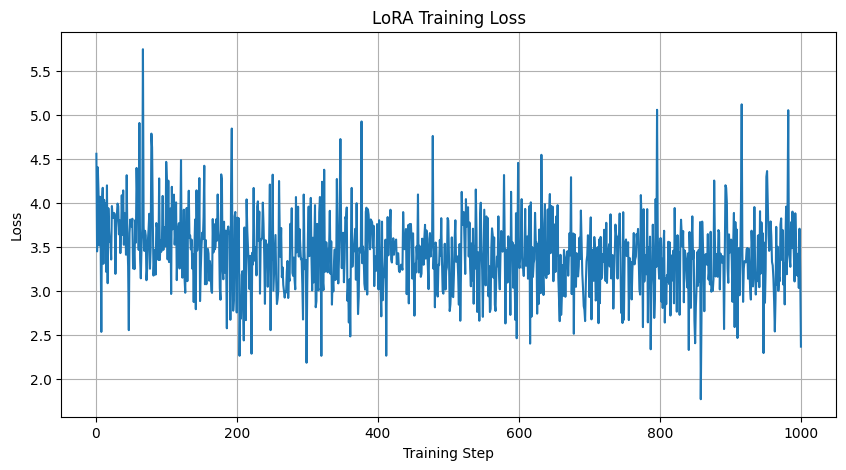

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(training_losses) + 1),
    training_losses
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("LoRA Training Loss")
plt.grid(True)

plt.show()

### 55. Calculate Smoothed Training Loss

Individual batch losses can fluctuate considerably.

We will calculate a moving average to make the overall
training trend easier to observe.

The smoothing is only for visualization and does not
change the actual training loss.

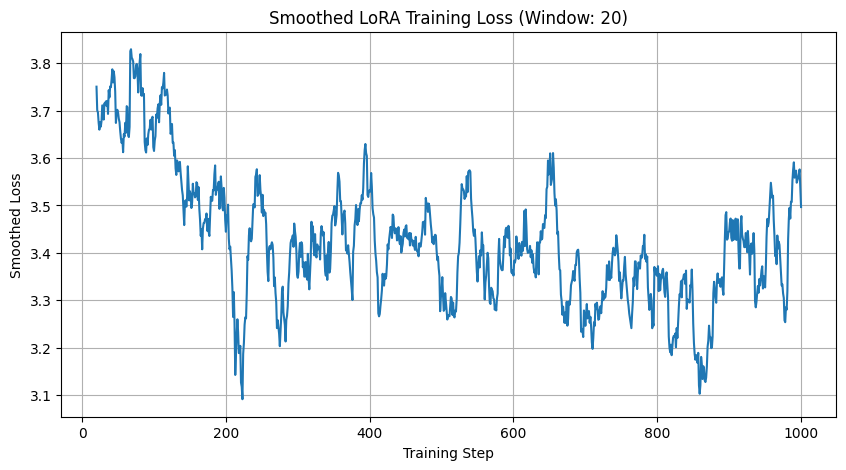

In [75]:
import numpy as np

SMOOTHING_WINDOW = 20

if len(training_losses) >= SMOOTHING_WINDOW:
    smoothed_losses = np.convolve(
        training_losses,
        np.ones(SMOOTHING_WINDOW) / SMOOTHING_WINDOW,
        mode="valid"
    )

    smoothed_steps = range(
        SMOOTHING_WINDOW,
        len(training_losses) + 1
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        smoothed_steps,
        smoothed_losses
    )

    plt.xlabel("Training Step")
    plt.ylabel("Smoothed Loss")
    plt.title(
        f"Smoothed LoRA Training Loss "
        f"(Window: {SMOOTHING_WINDOW})"
    )
    plt.grid(True)

    plt.show()

else:
    print(
        "Not enough training steps for the selected "
        "smoothing window."
    )

### 56. Compare Training and Validation Loss

We will compare the average training loss with the
validation loss calculated in Level 8.

A difference between training and validation loss can
provide useful information about the model's behavior,
but a single training run is not sufficient to establish
overfitting conclusively.

Average training loss: 3.4287
Validation loss: 3.1922


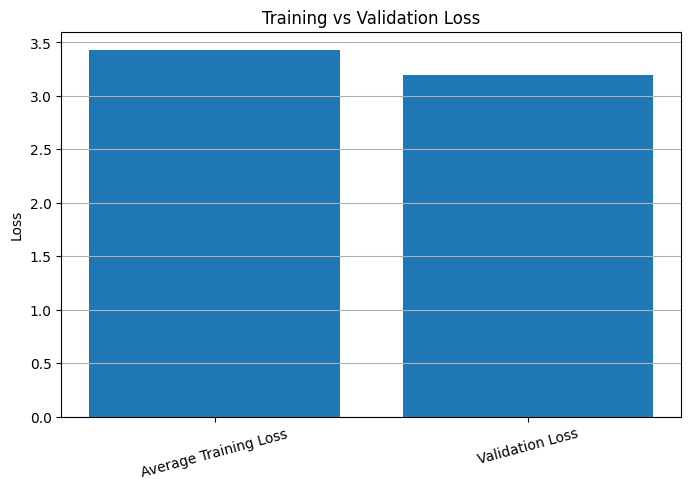

In [76]:
average_training_loss = sum(training_losses) / len(
    training_losses
)

print(f"Average training loss: {average_training_loss:.4f}")
print(f"Validation loss: {finetuned_validation_loss:.4f}")

loss_comparison = {
    "Average Training Loss": average_training_loss,
    "Validation Loss": finetuned_validation_loss
}

plt.figure(figsize=(8, 5))

plt.bar(
    loss_comparison.keys(),
    loss_comparison.values()
)

plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.xticks(rotation=15)
plt.grid(axis="y")

plt.show()

### 57. Save the Training Loss Plot

The plot will be saved as a PNG file.

This image can be included in the GitHub README
or the project's results documentation.

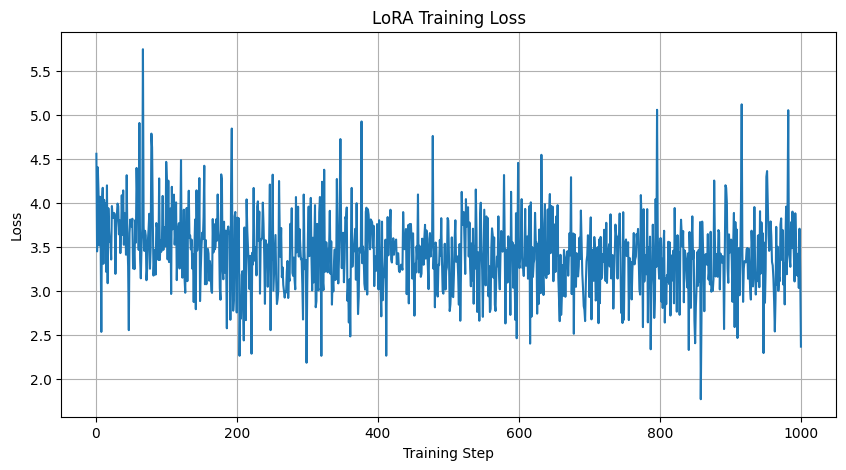

Training loss plot saved as lora_training_loss.png


In [77]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(training_losses) + 1),
    training_losses
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("LoRA Training Loss")
plt.grid(True)

plt.savefig(
    "lora_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Training loss plot saved as lora_training_loss.png")

### 58. Record Training Observations

Review the plots and record the following observations:

- Does the training loss generally decrease?
- Are there large fluctuations between batches?
- How does the validation loss compare with the training loss?
- Are there any indications that additional training
  or hyperparameter tuning may be needed?

These observations will be used when documenting the
experimental results.

In [78]:
training_observations = {
    "loss_trend": "",
    "loss_fluctuations": "",
    "training_validation_comparison": "",
    "possible_improvements": ""
}

for criterion in training_observations:
    print(f"{criterion}: ______________________________")

loss_trend: ______________________________
loss_fluctuations: ______________________________
training_validation_comparison: ______________________________
possible_improvements: ______________________________
